In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
procs = np.arange(1,25)
TimesStatic = np.load('TimesStatic100.npy')
SpeedupStatic = np.load('SpeedupStatic100.npy')
TimesDynamic = np.load('TimesDynamic100.npy')
SpeedupDynamic = np.load('SpeedupDynamic100.npy')

# Speedup

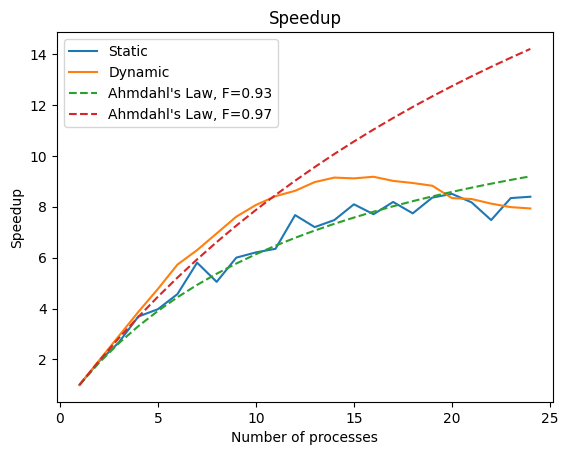

In [5]:
plt.plot(procs, SpeedupStatic, label='Static')
plt.plot(procs, SpeedupDynamic, label='Dynamic')

# Fit curve from Amdahl's Law
F_stat = 0.93
F_dyn = 0.97
plt.plot(procs, 1 / ((1-F_stat) + F_stat/procs), '--', label=f"Ahmdahl's Law, F={F_stat}")
plt.plot(procs, 1 / ((1-F_dyn) + F_dyn/procs), '--', label=f"Ahmdahl's Law, F={F_dyn}")

plt.legend()
plt.title('Speedup')
plt.xlabel('Number of processes')
plt.ylabel('Speedup')
plt.show()

Theoretical maximum speedup according to Amdahl's law (given the estimated parallel fractions)

In [6]:
print(f"Static implementation: {np.round(1 / (1-F_stat), 3)}")
print(f"Dynamic implementation: {np.round(1 / (1-F_dyn), 3)}")

Static implementation: 14.286
Dynamic implementation: 33.333


# Time consumption

In [7]:
# Total number of floorplans
total = 9142 / 2

print(f"STATIC IMPLEMENTATION")
print(f"Fastest run (100 floorplans): {np.round(np.min(TimesStatic), 3)} s")
print(f"Processes used: {np.where(TimesStatic == np.min(TimesStatic))[0][0] + 1}")
print(f"Estimated for all floorplans: {np.round(np.min(TimesStatic) / 100 * total, 3)} s = {np.round(np.min(TimesStatic) / 100 * total / (60**2), 3)} h")

print(f"\nDYNAMIC IMPLEMENTATION")
print(f"Fastest run (100 floorplans): {np.round(np.min(TimesDynamic), 3)} s")
print(f"Processes used: {np.where(TimesDynamic == np.min(TimesDynamic))[0][0] + 1}")
print(f"Estimated for all floorplans: {np.round(np.min(TimesDynamic) / 100 * total, 3)} s = {np.round(np.min(TimesDynamic) / 100 * total / (60**2), 3)} h")

STATIC IMPLEMENTATION
Fastest run (100 floorplans): 187.338 s
Processes used: 20
Estimated for all floorplans: 8563.221 s = 2.379 h

DYNAMIC IMPLEMENTATION
Fastest run (100 floorplans): 289.639 s
Processes used: 16
Estimated for all floorplans: 13239.409 s = 3.678 h


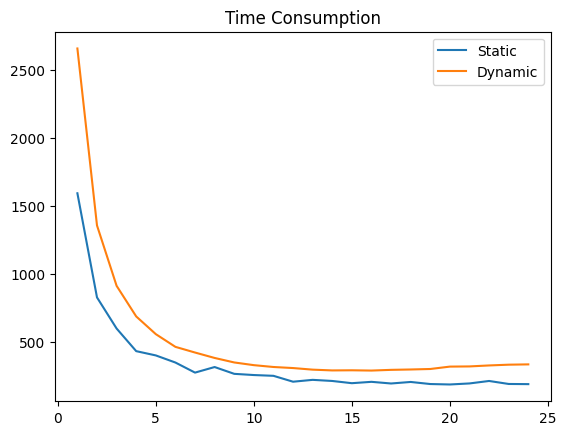

In [9]:
plt.plot(procs, TimesStatic, label='Static')
plt.plot(procs, TimesDynamic, label='Dynamic')
plt.legend()
plt.title('Time Consumption')
plt.show()

In [10]:
TimesStatic

array([1593.59137887,  827.67136823,  598.80865995,  432.47912927,
        401.01474527,  348.71855457,  274.59743878,  315.61008272,
        265.58597067,  256.73415046,  251.03350827,  207.72181342,
        221.32348374,  213.14734859,  196.81948686,  206.80523517,
        194.60720623,  205.85908544,  190.59229301,  187.33801231,
        194.96167394,  213.11160509,  191.05581433,  189.85035729])

In [11]:
TimesDynamic

array([2658.44994462, 1356.95384124,  912.8563247 ,  687.71721905,
        557.53072124,  464.02713061,  422.31110833,  382.39004272,
        349.30384199,  329.45405747,  315.93725457,  308.15827879,
        296.39080271,  290.66995362,  291.66932819,  289.63922195,
        294.85328024,  297.59168494,  301.21178264,  318.76605407,
        320.12222466,  327.28794427,  332.93012999,  335.13471088])